Imports:

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.parser import NSL_KDD_COLUMNS

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='darkgrid')

Matplotlib is building the font cache; this may take a moment.


Load Data:

In [2]:
df = pd.read_csv('../data/raw/KDDTrain+.csv', header=None, names=NSL_KDD_COLUMNS)
print(f'Shape: {df.shape}')
df.head()

Shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Basic info:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

Missing values:

In [4]:
missing = df.isnull().sum()
print('Missing values:', missing[missing > 0].to_dict() or 'None')

Missing values: None


Class Dist:

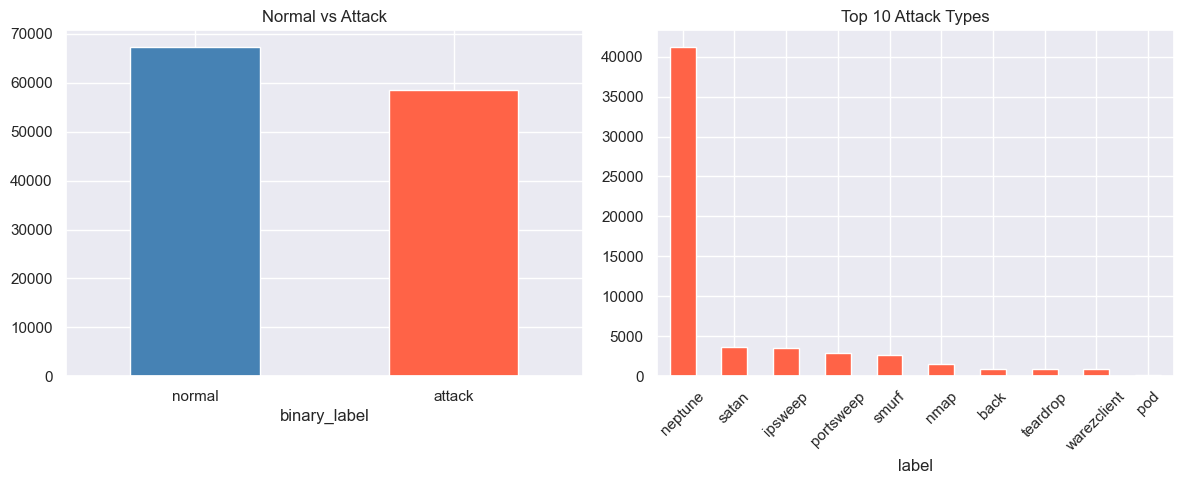

In [5]:
df['binary_label'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

fig, axes = plt.subplots(1, 2)

df['binary_label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Normal vs Attack')
axes[0].tick_params(axis='x', rotation=0)

df[df['label'] != 'normal']['label'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Top 10 Attack Types')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Attack Categories

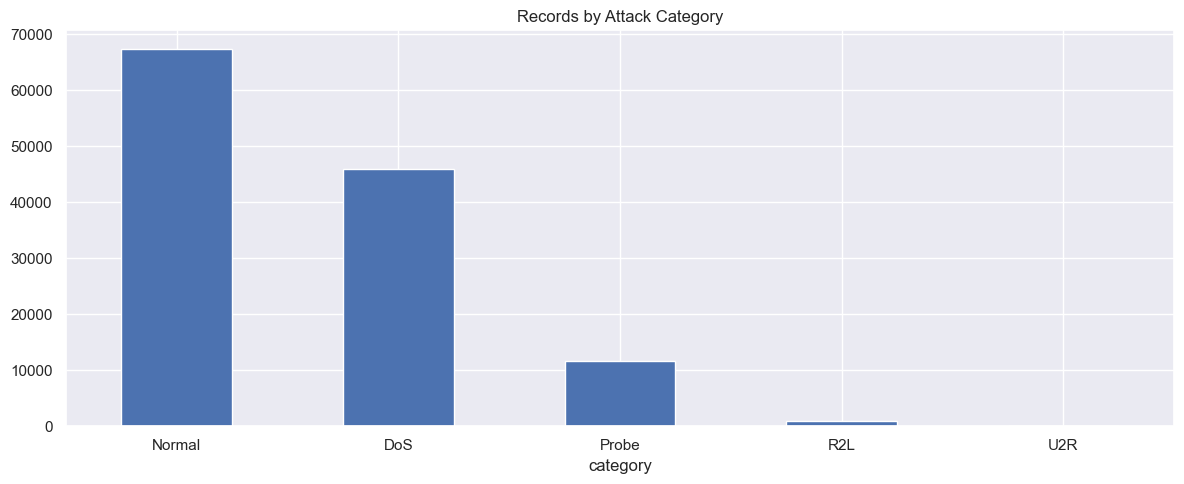

In [6]:
DOS   = {'back','land','neptune','pod','smurf','teardrop','apache2','udpstorm','processtable','mailbomb'}
PROBE = {'ipsweep','nmap','portsweep','satan','mscan','saint'}
R2L   = {'ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster',
         'sendmail','named','snmpgetattack','snmpguess','worm','xlock','xsnoop','httptunnel'}
U2R   = {'buffer_overflow','loadmodule','perl','rootkit','ps','sqlattack','xterm'}

def categorise(label):
    if label == 'normal': return 'Normal'
    if label in DOS:      return 'DoS'
    if label in PROBE:    return 'Probe'
    if label in R2L:      return 'R2L'
    if label in U2R:      return 'U2R'
    return 'Other'

df['category'] = df['label'].apply(categorise)
df['category'].value_counts().plot(kind='bar')
plt.title('Records by Attack Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Protocol and service 

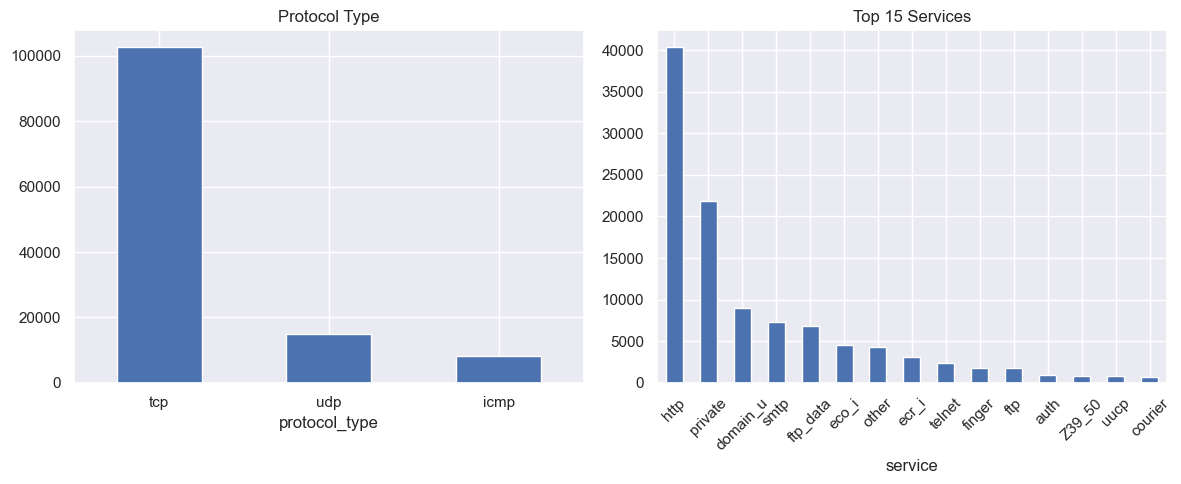

In [7]:
fig, axes = plt.subplots(1, 2)

df['protocol_type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Protocol Type')
axes[0].tick_params(axis='x', rotation=0)

df['service'].value_counts().head(15).plot(kind='bar', ax=axes[1])
axes[1].set_title('Top 15 Services')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Numeric dist

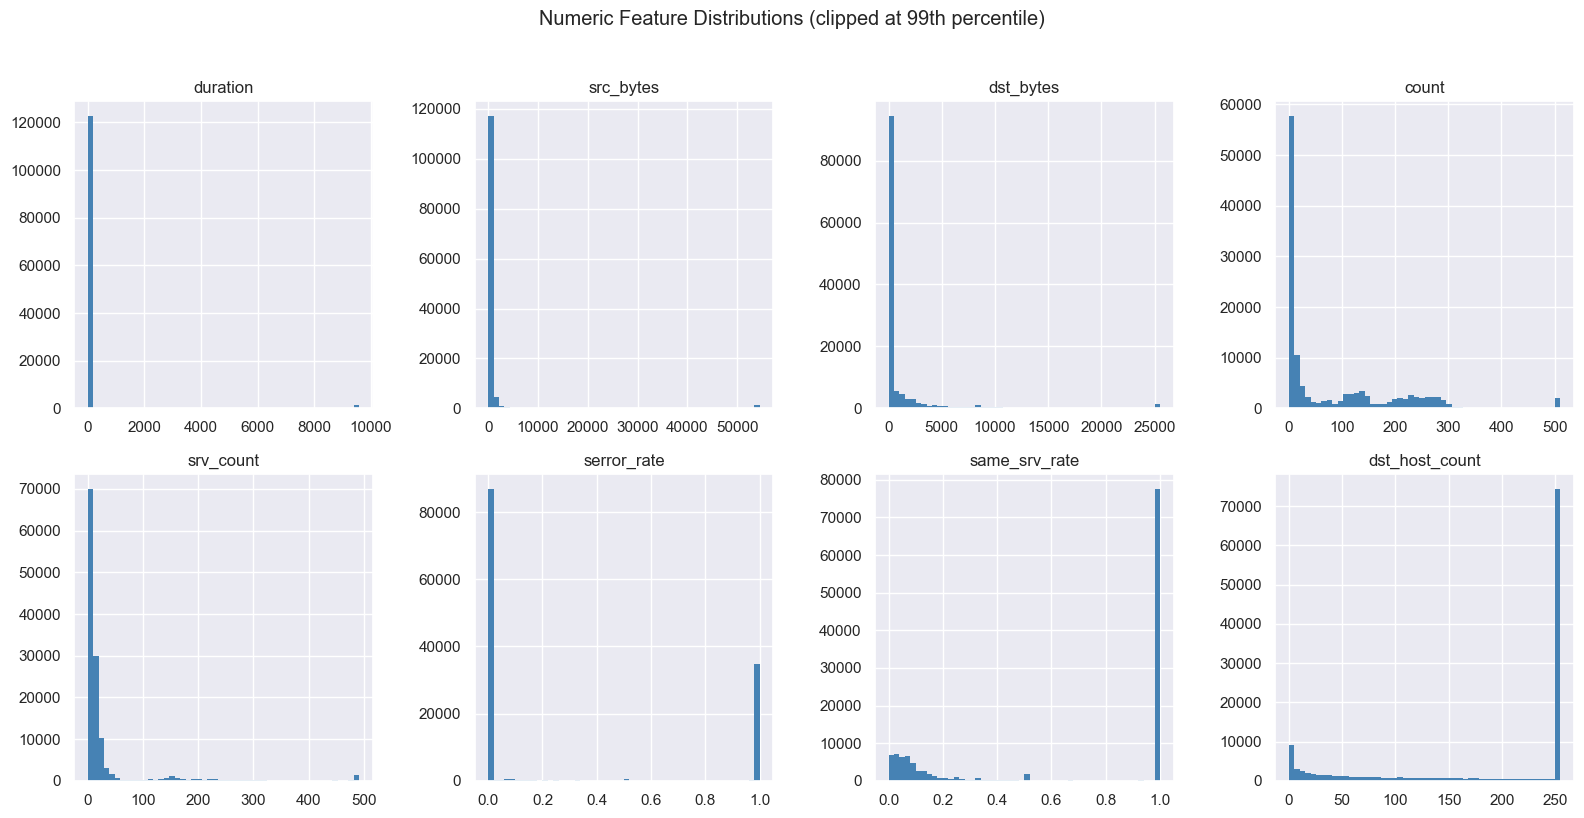

In [8]:
numeric_cols = ['duration', 'src_bytes', 'dst_bytes', 'count',
                'srv_count', 'serror_rate', 'same_srv_rate', 'dst_host_count']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].clip(upper=df[col].quantile(0.99)).hist(ax=axes[i], bins=50, color='steelblue', edgecolor='none')
    axes[i].set_title(col)

plt.suptitle('Numeric Feature Distributions (clipped at 99th percentile)', y=1.02)
plt.tight_layout()
plt.show()

Correlation heatmap

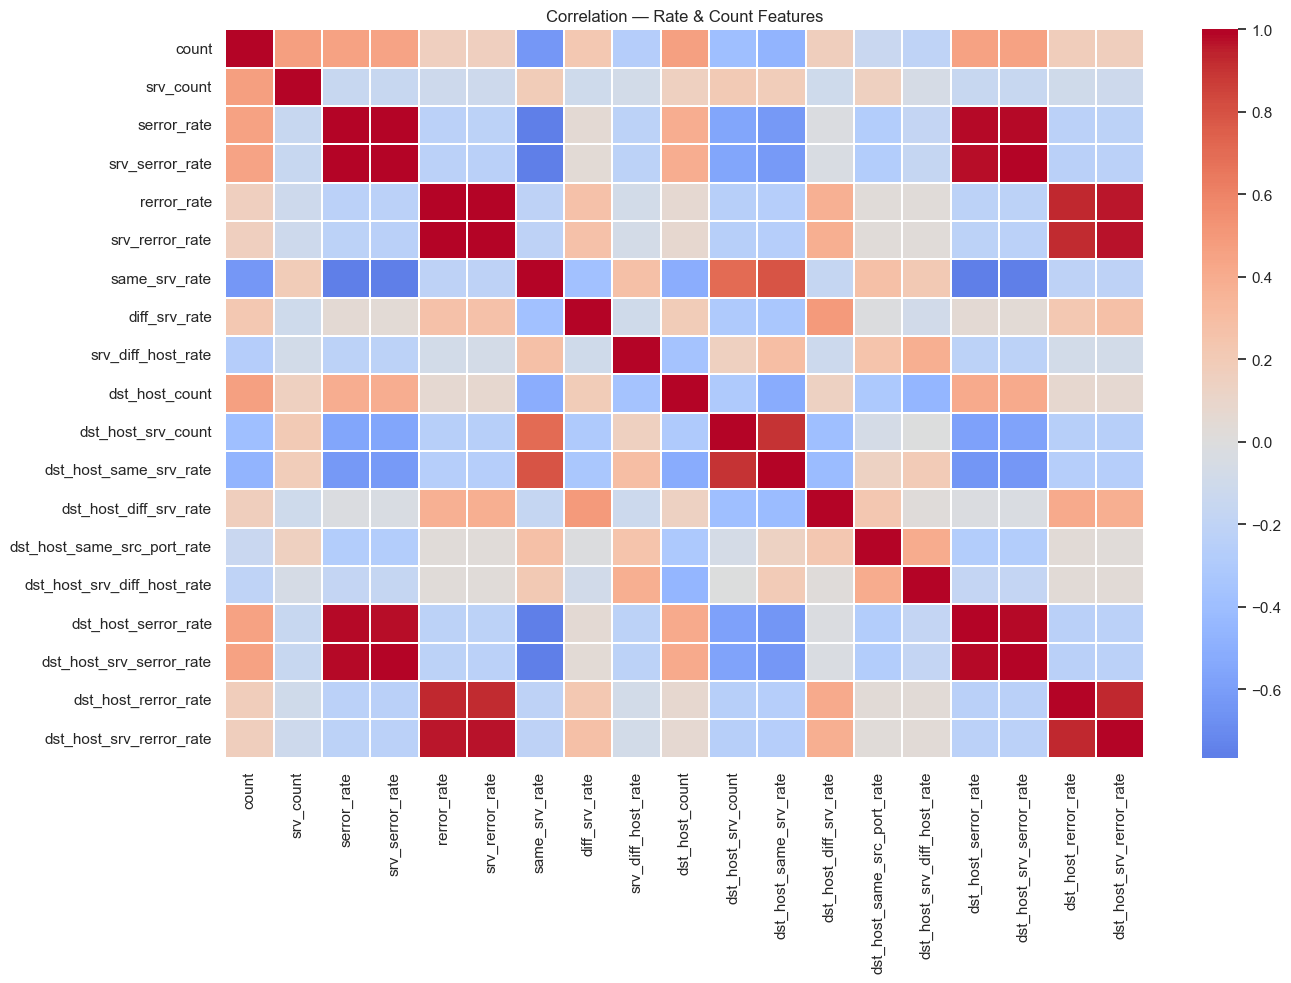

In [9]:
rate_cols = [c for c in df.columns if 'rate' in c or 'count' in c]
corr = df[rate_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation — Rate & Count Features')
plt.tight_layout()
plt.show()

Low variance features 

Low-variance features (<0.01): ['num_outbound_cmds', 'is_host_login', 'land', 'urgent', 'num_shells', 'root_shell', 'su_attempted', 'num_failed_logins', 'is_guest_login', 'num_access_files']


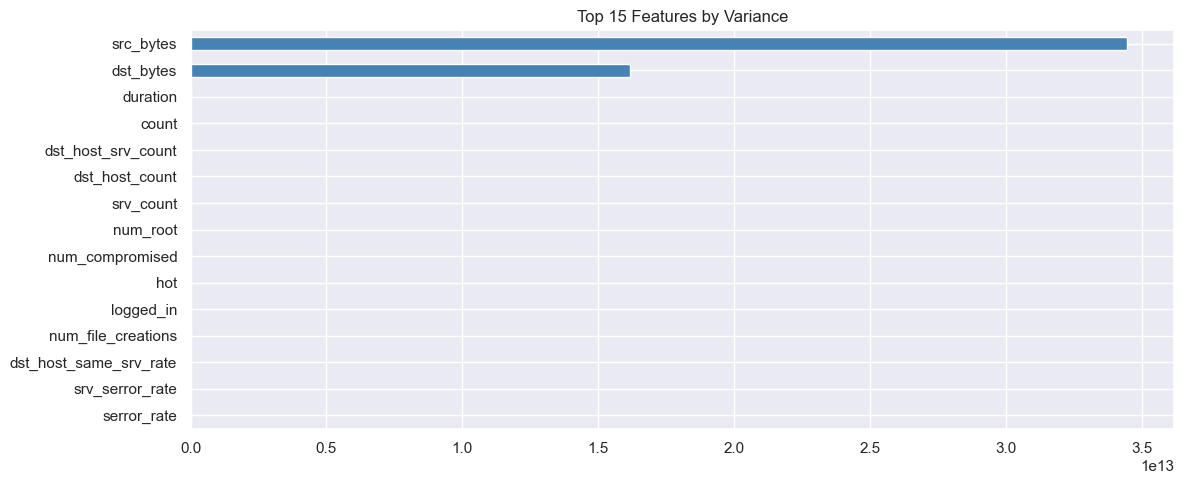

In [10]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['difficulty'])
variance = numeric_df.var().sort_values()

low_var = variance[variance < 0.01]
print(f'Low-variance features (<0.01): {list(low_var.index)}')

variance.tail(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features by Variance')
plt.tight_layout()
plt.show()